<a href="https://colab.research.google.com/github/SarthakGupta345/PytorchLearning/blob/main/simpleLangraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -qU langgraph langchain langchain-groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.3 MB/s eta 0:00:00


In [2]:
import os
import json
import getpass
from typing import TypedDict, List

from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END


In [3]:
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")


Enter your Groq API key: ··········


In [5]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0,              # deterministic
    max_tokens=100,              # hard limit
    reasoning_format="parsed",  # no chain-of-thought
    timeout=10,
    max_retries=1,
)


In [6]:
class State(TypedDict):
    text: str
    classification: str
    entities: List[str]
    summary: str


In [14]:
CLASSIFICATION_PROMPT = PromptTemplate(
    input_variables=["text"],
    template=(
        "Classify the text into ONE WORD only.\n"
        "Options: News | Blog | Research | Other\n\n"
        "Text:\n{text}\n\n"
        "Answer:"
    ),
)

ENTITY_PROMPT = PromptTemplate(
    input_variables=["text"],
    template=(
        "Extract entities of type Person, Organization, Location.\n"
        "Return ONLY valid JSON.\n\n"
        "Text:\n{text}\n\n"
        "JSON:\n"
        '"entities": ["..."]'
    ),
)

SUMMARY_PROMPT = PromptTemplate(
    input_variables=["text"],
    template=(
        "Summarize the text in ONE short sentence.\n\n"
        "Text:\n{text}\n\n"
        "Summary:"
    ),
)


In [15]:
def classification_node(state: State):
    response = llm.invoke(
        CLASSIFICATION_PROMPT.format(text=state["text"])
    )
    return {"classification": response.content.strip()}


In [16]:
def entity_extraction_node(state: State):
    response = llm.invoke(
        ENTITY_PROMPT.format(text=state["text"])
    )
    try:
        data = json.loads(response.content)
        entities = data.get("entities", [])
    except json.JSONDecodeError:
        entities = []

    return {"entities": entities}


In [17]:
def summarization_node(state: State):
    response = llm.invoke(
        SUMMARY_PROMPT.format(text=state["text"])
    )
    return {"summary": response.content.strip()}


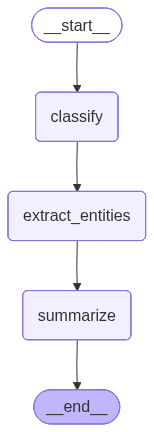

In [21]:
workflow = StateGraph(State)

workflow.add_node("classify", classification_node)
workflow.add_node("extract_entities", entity_extraction_node)
workflow.add_node("summarize", summarization_node)

workflow.set_entry_point("classify")
workflow.add_edge("classify", "extract_entities")
workflow.add_edge("extract_entities", "summarize")
workflow.add_edge("summarize", END)

app = workflow.compile()
app

In [19]:
sample_text = """
The recent advancements in quantum computing have opened new possibilities
for cryptography and data security. Researchers at MIT and Google have
demonstrated quantum algorithms that could potentially break current
encryption methods.
"""


In [22]:
from langchain_core.prompts import ChatPromptTemplate
prompts = ChatPromptTemplate.from_messages([
    ("system", "classify userinput into news, Blogs,Reserach,Other any one of them"),
    ("human", "{text}"),
])

In [24]:
response = llm.invoke(
    prompts.format_prompt(text=sample_text).to_messages()
)
print(response)

content='News' additional_kwargs={'reasoning_content': "The user input is a short text about quantum computing advancements, cryptography, research. This is likely a research article or news? It's describing recent advancements, could be news. The classification categories: news, Blogs, Research, Other. The content is about recent advancements, could be news. It's not a blog style personal opinion, more like a news report. So classify as news."} response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 133, 'total_tokens': 221, 'completion_time': 0.192147604, 'completion_tokens_details': {'reasoning_tokens': 78}, 'prompt_time': 0.005444705, 'prompt_tokens_details': None, 'queue_time': 0.018739663, 'total_time': 0.197592309}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_bb691ea66b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019bbbe8-7aaf-71f2-8fd8-bcac8c7a768d-0' tool_calls=[] invali

In [20]:
result = app.invoke({"text": sample_text})

print("Classification:", result["classification"])
print("Entities:", result["entities"])
print("Summary:", result["summary"])


Classification: 
Entities: []
Summary: Recent quantum computing breakthroughs at MIT and Google could enable algorithms that break existing encryption methods.
